![Henry Logo](https://www.soyhenry.com/_next/static/media/HenryLogo.bb57fd6f.svg)



# M3L1 Extra E01 - Tool Contracts
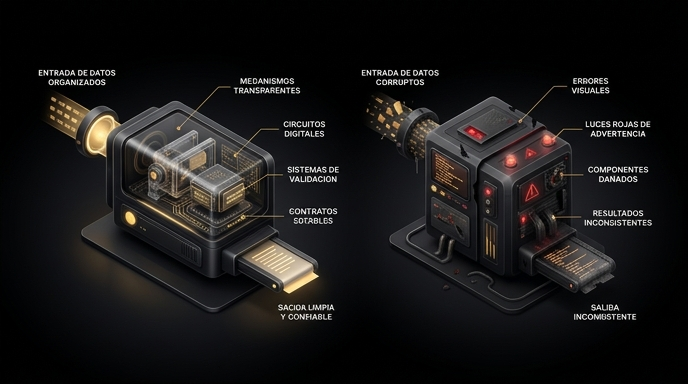
## Proposito

Este notebook trabaja una idea central: las tools conectan al agente con el mundo real, pero deben estar bien diseñadas.

Una **custom tool** productiva necesita:

- responsabilidad unica;
- inputs claros;
- outputs predecibles;
- validacion;
- errores interpretables;
- posibilidad de testearse de manera aislada.

En este ejercicio vas a revisar la solucion de tools para consultar ventas y calcular ingresos.


## Definiciones clave

| Concepto | Definicion | En este ejercicio |
|---|---|---|
| Tool contract | Forma estable de entrada y salida de una tool. | `fetch_sales()` devuelve siempre `success`, `period`, `sales`, `error`. |
| Input validation | Rechazar o normalizar entradas invalidas. | `normalize_period()` limpia y valida el periodo. |
| Error handling | Convertir fallos en mensajes interpretables. | `success=False` y `error` descriptivo. |
| Grounding | Basar la respuesta en datos reales. | Las ventas salen de `SALES_DB`. |
| Tool deterministica | Funcion verificable sin LLM. | `calculate_revenue()` calcula con Python. |

Idea clave: el LLM no deberia inventar datos ni calcular todo mentalmente si una tool puede hacerlo de forma mas confiable.


## C?mo encaja este notebook en un AI Agent

Este notebook no implementa el loop ReAct completo. Se enfoca en una pieza previa: que las **tools** sean confiables.

En una arquitectura de agente, estas funciones entrarian asi:

```text
Thought: necesito consultar ventas del periodo.
Action: fetch_sales("2024-W01")
Observation: {"success": True, "sales": [...]}

Thought: ahora necesito calcular el total.
Action: calculate_revenue(sales)
Observation: {"success": True, "total_usd": 100}
```

La observacion es util porque la tool devuelve un contrato estable. Si el contrato cambia todo el tiempo, el agente no puede construir un trace confiable ni decidir la accion a tomar.


## Solucion paso 1 - Fuente de datos

La fuente queda igual que en Starter. Lo que cambia es que ahora las tools la consultan con validacion y contrato estable.


In [ ]:
SALES_DB = {
    "2024-W01": [
        {"product": "Pro", "units": 3, "unit_price_usd": 20},
        {"product": "Starter", "units": 5, "unit_price_usd": 8},
    ]
}


## Solucion TODO 1 - `normalize_period()`

La solucion valida tipo, limpia espacios, normaliza mayusculas y rechaza strings vacios.

Esto aplica validacion en frontera: antes de consultar datos, convertimos el input externo en una forma interna segura.


In [ ]:
def normalize_period(period):
    if not isinstance(period, str):
        return None
    normalized = period.strip().upper()
    return normalized or None


## Solucion TODO 2 - `fetch_sales()`

La solucion devuelve siempre el mismo shape. Eso es importante porque el agente puede leer `success` y `error` para decidir la accion a tomar.


In [ ]:
def fetch_sales(period):
    normalized = normalize_period(period)
    if normalized is None:
        return {
            "success": False,
            "period": None,
            "sales": [],
            "error": "period must be a non-empty string",
        }

    sales = SALES_DB.get(normalized)
    if sales is None:
        return {
            "success": False,
            "period": normalized,
            "sales": [],
            "error": f"no sales for period {normalized}",
        }

    return {"success": True, "period": normalized, "sales": sales, "error": None}


## Solucion TODO 3 - `calculate_revenue()`

La solucion calcula de forma deterministica, convierte tipos y captura errores.

Esto evita que el LLM tenga que adivinar el total o interpretar datos inconsistentes.


In [ ]:
def calculate_revenue(sales):
    if not isinstance(sales, list) or not sales:
        return {"success": False, "total_usd": 0, "error": "sales must be a non-empty list"}

    try:
        total = 0
        for record in sales:
            units = int(record["units"])
            price = float(record["unit_price_usd"])
            total += units * price
    except (KeyError, TypeError, ValueError) as exc:
        return {"success": False, "total_usd": 0, "error": str(exc)}

    return {"success": True, "total_usd": total, "error": None}


## Ejecutar Resolution

Los checks demuestran que las tools se pueden probar de manera aislada antes de integrarlas a un agente.


In [ ]:
def run_checks():
    ok = fetch_sales(" 2024-w01 ")
    assert ok["success"] is True
    assert ok["period"] == "2024-W01"
    total = calculate_revenue(ok["sales"])
    assert total["success"] is True
    assert total["total_usd"] == 100

    missing = fetch_sales("2024-W99")
    assert missing["success"] is False
    assert missing["sales"] == []

    bad = fetch_sales(None)
    assert bad["success"] is False

    print("M3L1 E01 Resolution checks passed")


run_checks()


## Cierre

Este Resolution muestra el patron recomendado para custom tools:

```text
validar input -> consultar o calcular -> devolver output estable -> reportar error seguro
```

Este patron es la base del agente del hands-on principal.
